# Neural Additive Model (NAM) for Power Grid Voltage Prediction

This notebook implements a Neural Additive Model (NAM) to predict voltage magnitudes at 33 buses of a power distribution network. We'll compare NAM's performance and interpretability with XGBoost and Random Forest models using SHAP values.

## 1. Import Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, regularizers
import shap

# Set seaborn style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 2. Load and Explore the Dataset

In [16]:
# Load the .mat file
data = scipy.io.loadmat('verilerPV.mat')

# Extract input features and output voltage magnitudes
# Assuming the data is stored as 'X' for inputs and 'Y' for outputs
# Check the keys in the .mat file and adjust if necessary
print("Keys in the .mat file:", data.keys())

# Extract input and output data
# Replace 'X' and 'Y' with actual keys from the data file if different
X = data.get('X', None)
Y = data.get('Y', None)

if X is None or Y is None:
    # Try alternative keys that might be present in the file
    potential_input_keys = ['input', 'inputs', 'features', 'x', 'X_data']
    potential_output_keys = ['output', 'outputs', 'targets', 'y', 'Y_data', 'voltages']
    
    for key in potential_input_keys:
        if key in data:
            X = data[key]
            break
    
    for key in potential_output_keys:
        if key in data:
            Y = data[key]
            break

# If we still don't have the data, use the first two non-standard keys
if X is None or Y is None:
    non_standard_keys = [key for key in data.keys() if not key.startswith('__')]
    if len(non_standard_keys) >= 2:
        # Assume the first array is input and the second is output
        potential_arrays = [data[key] for key in non_standard_keys if isinstance(data[key], np.ndarray)]
        arrays_by_shape = sorted(potential_arrays, key=lambda arr: arr.shape[1])
        if len(arrays_by_shape) >= 2:
            # Assuming input has fewer features than output has dimensions
            X = arrays_by_shape[0]
            Y = arrays_by_shape[1]

# Check if the data was successfully loaded
if X is not None and Y is not None:
    print("Input shape:", X.shape)
    print("Output shape:", Y.shape)
else:
    raise ValueError("Could not identify input and output data in the .mat file")

# Create feature names based on the project description
feature_names = ['Tap1', 'Tap2', 'PV1loc', 'PV2loc', 'PV3loc', 'PV4loc', 'PV5loc', 
                 'PV1size', 'PV2size', 'PV3size', 'PV4size', 'PV5size']
output_names = [f'V{i}' for i in range(1, 34)]

# Convert to DataFrame for easier handling
X_df = pd.DataFrame(X, columns=feature_names)
Y_df = pd.DataFrame(Y, columns=output_names)
X_df.info()
Y_df.info()

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'cikti', 'girdi'])
Input shape: (2000, 12)
Output shape: (2000, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tap1     2000 non-null   float64
 1   Tap2     2000 non-null   float64
 2   PV1loc   2000 non-null   float64
 3   PV2loc   2000 non-null   float64
 4   PV3loc   2000 non-null   float64
 5   PV4loc   2000 non-null   float64
 6   PV5loc   2000 non-null   float64
 7   PV1size  2000 non-null   float64
 8   PV2size  2000 non-null   float64
 9   PV3size  2000 non-null   float64
 10  PV4size  2000 non-null   float64
 11  PV5size  2000 non-null   float64
dtypes: float64(12)
memory usage: 187.6 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  -------------- 

### 2.1 Basic Statistics

In [17]:
# Basic statistics for input features
print("\nInput Features Statistics:")
X_stats = X_df.describe()
display(X_stats)

# Basic statistics for output voltages
print("\nOutput Voltages Statistics:")
Y_stats = Y_df.describe()
display(Y_stats.T.head())  # Transpose and show first few buses


Input Features Statistics:


,Tap1,Tap2,PV1loc,PV2loc,PV3loc,PV4loc,PV5loc,PV1size,PV2size,PV3size,PV4size,PV5size
count,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.29600,0.26050,17.277000,17.567500,17.703000,17.47350,17.726500,100.197799,99.037587,100.401112,96.423688,100.792858
std,9.63394,9.43192,9.171441,9.363401,9.234199,9.13696,9.257783,57.542589,58.067429,57.211559,58.384071,57.489776
min,-16.00000,-16.00000,2.000000,2.000000,2.000000,2.00000,2.000000,0.029963,0.072714,0.044583,0.163506,0.039530
25%,-8.00000,-8.00000,10.000000,9.000000,10.000000,10.00000,10.000000,48.921996,47.260101,51.314179,45.417797,50.725881
50%,0.00000,1.00000,17.000000,17.000000,18.000000,17.50000,18.000000,101.720362,99.078139,100.649559,94.087182,103.041361
75%,9.00000,8.00000,25.000000,26.000000,26.000000,25.00000,25.000000,149.907738,150.164419,151.441112,147.726466,150.686303
max,16.00000,16.00000,33.000000,33.000000,33.000000,33.00000,33.000000,199.979564,199.950625,199.941505,199.884523,199.948465



Output Voltages Statistics:


,count,mean,std,min,25%,50%,75%,max
V1,2000.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
V2,2000.0,0.992058,0.002794,0.952672,0.990902,0.992401,0.993597,1.007313
V3,2000.0,0.942794,0.021265,0.675229,0.933922,0.944020,0.953210,1.095849
V4,2000.0,0.913254,0.030434,0.595641,0.899967,0.915462,0.929211,1.132085
V5,2000.0,0.883625,0.040196,0.482702,0.865743,0.887171,0.905531,1.172685


### 2.2 Feature Distributions

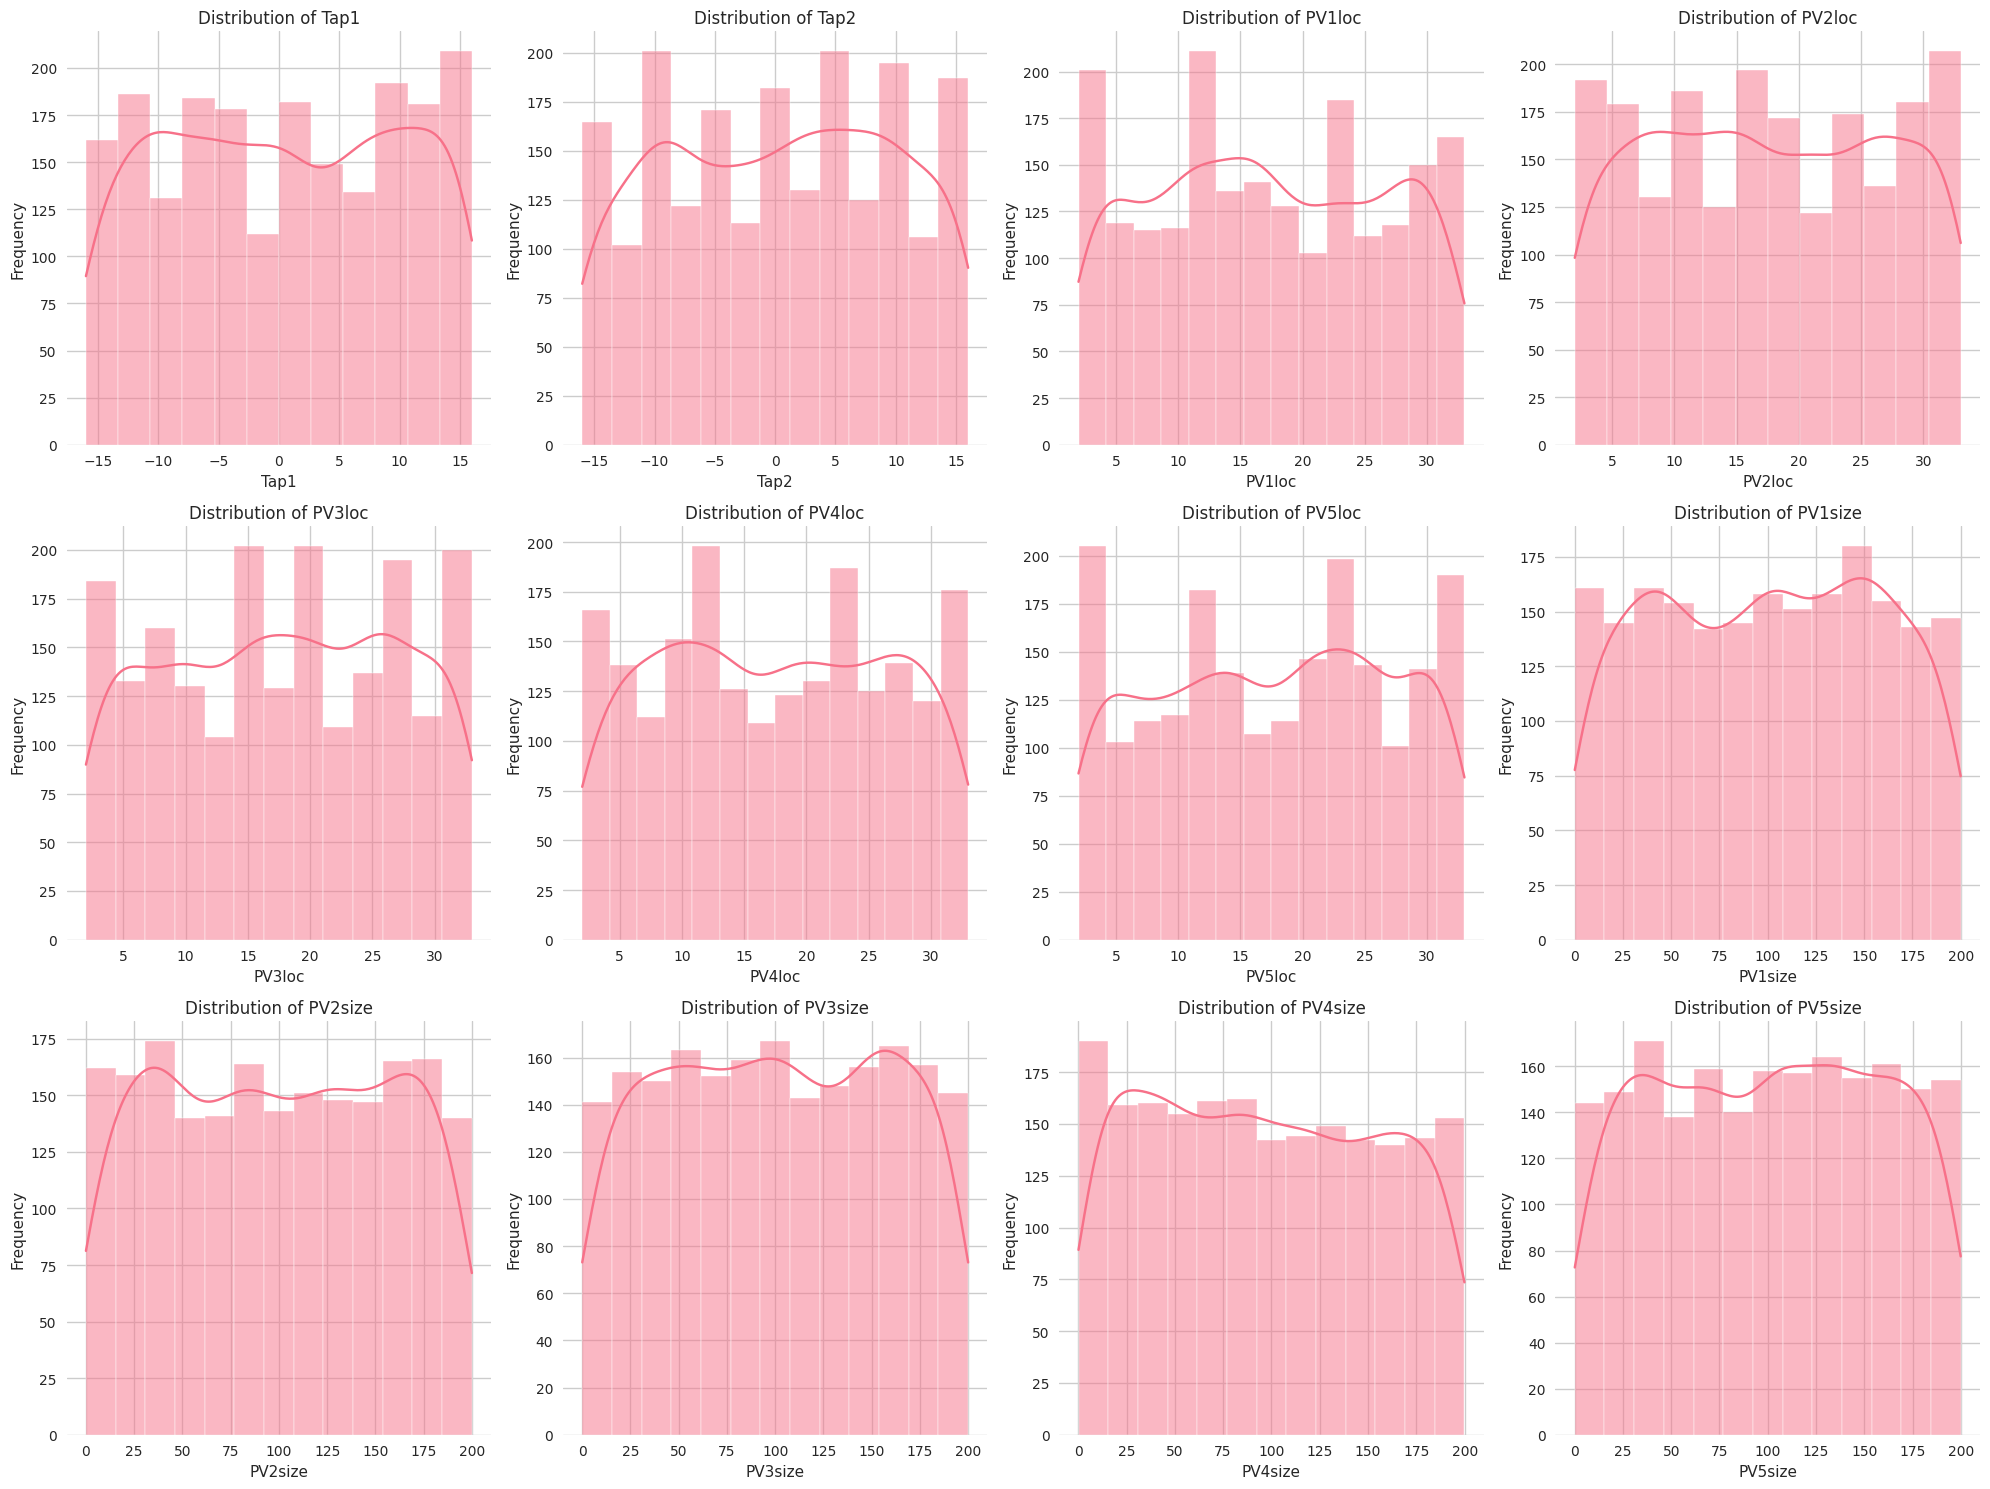

In [18]:
# Plot histograms for input features
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    sns.histplot(X_df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 2.3 Output Voltage Distributions

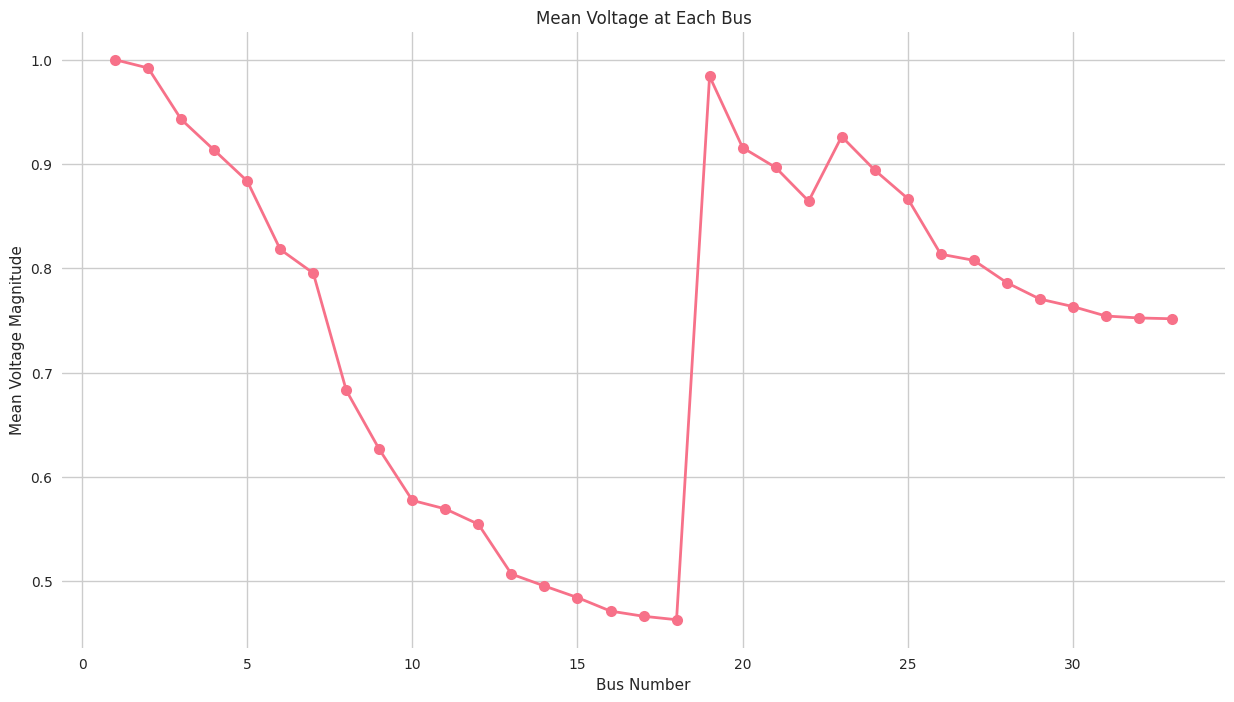

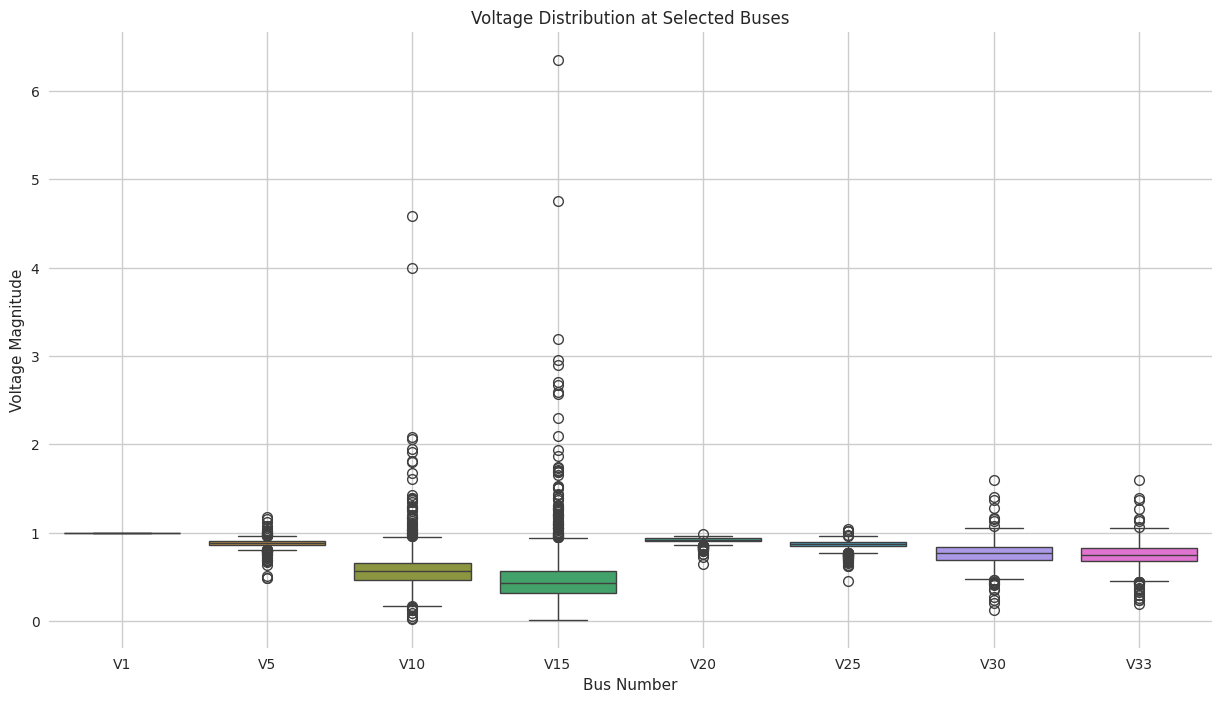

In [19]:
# Plot distributions of output voltages
plt.figure(figsize=(15, 8))

# Line plot showing mean voltage at each bus
mean_voltages = Y_df.mean()
plt.plot(range(1, 34), mean_voltages, 'o-', linewidth=2, markersize=8)
plt.title('Mean Voltage at Each Bus')
plt.xlabel('Bus Number')
plt.ylabel('Mean Voltage Magnitude')
plt.grid(True)
plt.show()

# Boxplot for selected buses (showing distribution across all samples)
selected_buses = ['V1', 'V5', 'V10', 'V15', 'V20', 'V25', 'V30', 'V33']
plt.figure(figsize=(15, 8))
sns.boxplot(data=Y_df[selected_buses])
plt.title('Voltage Distribution at Selected Buses')
plt.xlabel('Bus Number')
plt.ylabel('Voltage Magnitude')
plt.grid(True)
plt.show()

### 2.4 Correlation Analysis

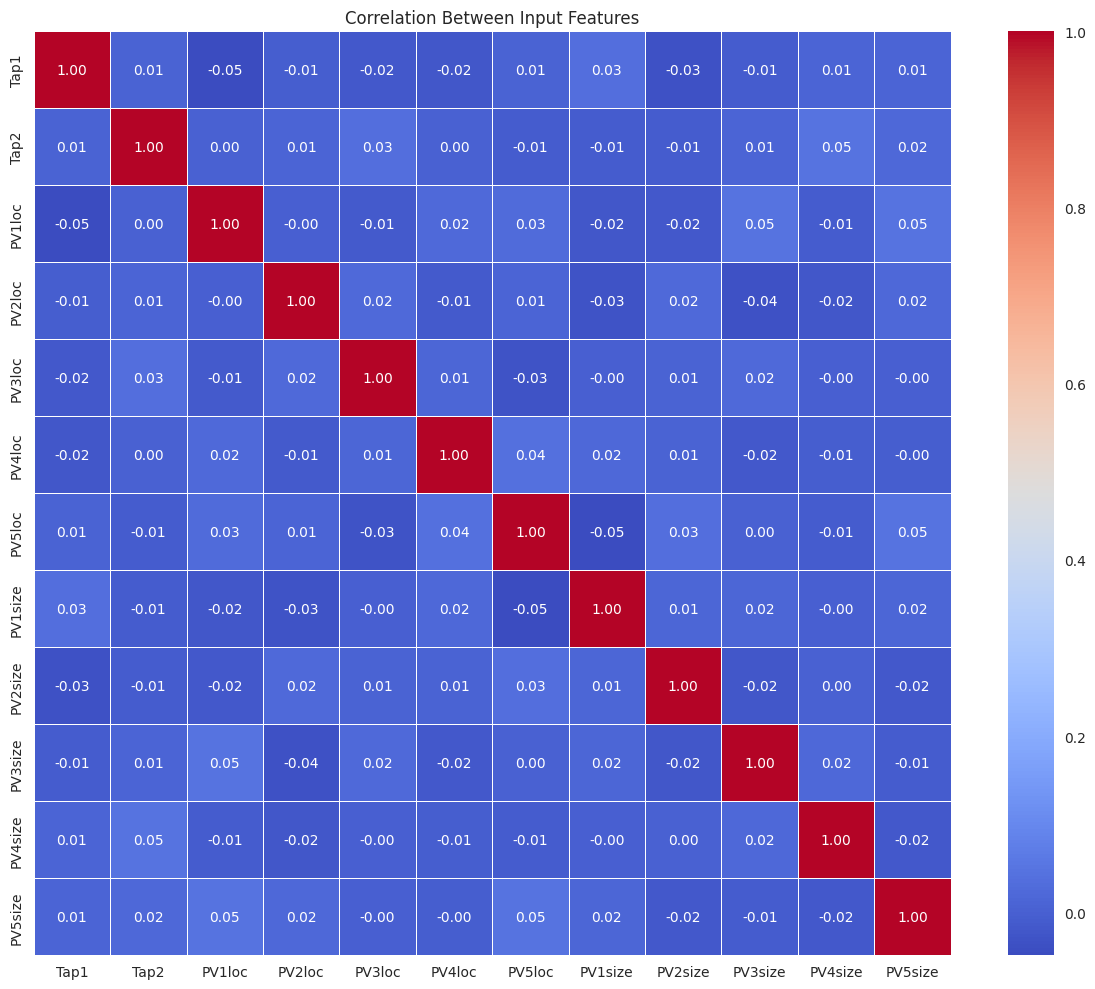

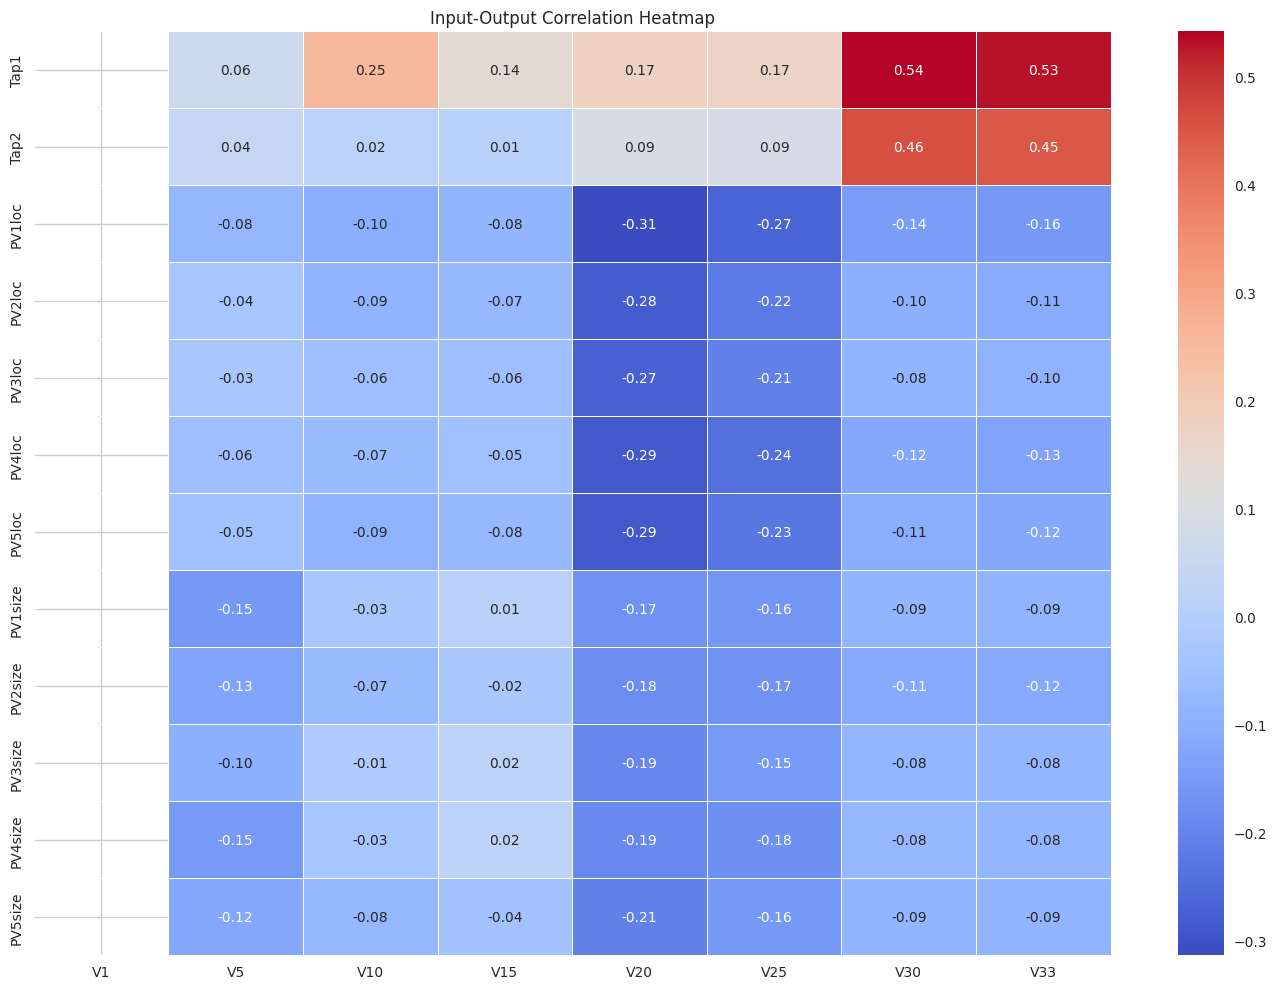

In [20]:
# Compute correlation between input features
input_corr = X_df.corr()

# Plot correlation heatmap for input features
plt.figure(figsize=(12, 10))
sns.heatmap(input_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Input Features')
plt.tight_layout()
plt.show()

# Compute correlation between each input feature and selected output voltages
# To prevent the heatmap from being too large, select a subset of output buses
selected_output_buses = ['V1', 'V5', 'V10', 'V15', 'V20', 'V25', 'V30', 'V33']
input_output_corr = pd.DataFrame(index=feature_names, columns=selected_output_buses)

for feature in feature_names:
    for bus in selected_output_buses:
        input_output_corr.loc[feature, bus] = np.corrcoef(X_df[feature], Y_df[bus])[0, 1]

# Convert all values to float
input_output_corr = input_output_corr.astype(float)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(input_output_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Input-Output Correlation Heatmap")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

In [21]:
# Normalize input features using StandardScaler
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_df)

# Split data: 80% training, 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape, Y_train.shape)
print("Testing set shape:", X_test.shape, Y_test.shape)

Training set shape: (1600, 12) (1600, 33)
Testing set shape: (400, 12) (400, 33)


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import warnings
warnings.filterwarnings('ignore')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

# %% [markdown]
# ## 2. Data Loading and Preprocessing

# %%
# Load datasets
input_data = pd.read_csv('input.csv')
output_data = pd.read_csv('output.csv')

# Create feature names based on the project description
feature_names = ['Tap1', 'Tap2', 'PV1loc', 'PV2loc', 'PV3loc', 'PV4loc', 'PV5loc', 'PV1size', 'PV2size',
'PV3size', 'PV4size', 'PV5size']
output_names = [f'V{i}' for i in range(1, 34)]
input_data.columns = feature_names
output_data.columns = output_names
print("Dataset Information:")
print(f"Input shape: {input_data.shape}")
print(f"Output shape: {output_data.shape}")
print(f"\nInput features: {list(input_data.columns)}")
print(f"Output features: {list(output_data.columns)}")

# Display basic statistics
print("\nInput data statistics:")
print(input_data.describe())

Libraries imported successfully!
TensorFlow version: 2.19.0
Dataset Information:
Input shape: (2000, 12)
Output shape: (2000, 33)

Input features: ['Tap1', 'Tap2', 'PV1loc', 'PV2loc', 'PV3loc', 'PV4loc', 'PV5loc', 'PV1size', 'PV2size', 'PV3size', 'PV4size', 'PV5size']
Output features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33']

Input data statistics:
             Tap1        Tap2       PV1loc       PV2loc       PV3loc  \
count  2000.00000  2000.00000  2000.000000  2000.000000  2000.000000   
mean      0.29600     0.26050    17.277000    17.567500    17.703000   
std       9.63394     9.43192     9.171441     9.363401     9.234199   
min     -16.00000   -16.00000     2.000000     2.000000     2.000000   
25%      -8.00000    -8.00000    10.000000     9.000000    10.000000   
50%       0.00000     1.00000    17

In [23]:
# Data preprocessing
X = input_data.values
y = output_data.values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set: X_test {X_test.shape}, y_test {y_test.shape}")

# Feature scaling
scaler = StandardScaler()  # You can change to MinMaxScaler() if preferred
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing completed!")

X shape: (2000, 12)
y shape: (2000, 33)

Train set: X_train (1600, 12), y_train (1600, 33)
Test set: X_test (400, 12), y_test (400, 33)
Data preprocessing completed!


In [24]:
class FeatureSubNetwork(keras.Model):
    """Individual feature subnetwork for NAM"""
    def __init__(self, hidden_units=[64, 32], dropout_rate=0.1):
        super(FeatureSubNetwork, self).__init__()
        self.hidden_layers = []
        
        for units in hidden_units:
            self.hidden_layers.append(layers.Dense(units, activation='relu'))
            self.hidden_layers.append(layers.Dropout(dropout_rate))
        
        self.output_layer = layers.Dense(1, activation='linear')
    
    def call(self, inputs, training=None):
        x = inputs
        for layer in self.hidden_layers:
            x = layer(x, training=training)
        return self.output_layer(x, training=training)

class NeuralAdditiveModel(keras.Model):
    """Neural Additive Model for multi-output regression"""
    def __init__(self, num_features, num_outputs, hidden_units=[64, 32], dropout_rate=0.1):
        super(NeuralAdditiveModel, self).__init__()
        self.num_features = num_features
        self.num_outputs = num_outputs
        
        # Create feature-specific subnetworks
        self.feature_nets = []
        for i in range(num_features):
            self.feature_nets.append(
                FeatureSubNetwork(hidden_units, dropout_rate)
            )
        
        # Output transformation layer
        self.output_transform = layers.Dense(num_outputs, activation='linear')
        
        # Bias term
        self.bias = self.add_weight(
            shape=(num_outputs,),
            initializer='zeros',
            trainable=True,
            name='bias'
        )
    
    def call(self, inputs, training=None):
        # Process each feature through its subnetwork
        feature_contributions = []
        for i in range(self.num_features):
            feature_input = tf.expand_dims(inputs[:, i], axis=-1)
            contribution = self.feature_nets[i](feature_input, training=training)
            feature_contributions.append(contribution)
        
        # Stack contributions
        stacked_contributions = tf.concat(feature_contributions, axis=-1)
        
        # Transform to output dimensions
        output = self.output_transform(stacked_contributions)
        
        # Add bias
        output = output + self.bias
        
        return output
    
    def get_feature_contributions(self, inputs):
        """Get individual feature contributions for interpretability"""
        contributions = {}
        feature_names = ['Tap1', 'Tap2', 'PV1loc', 'PV2loc', 'PV3loc', 'PV4loc', 'PV5loc', 
                        'PV1size', 'PV2size', 'PV3size', 'PV4size', 'PV5size']
        
        for i in range(self.num_features):
            feature_input = tf.expand_dims(inputs[:, i], axis=-1)
            contribution = self.feature_nets[i](feature_input, training=False)
            contributions[feature_names[i]] = contribution.numpy()
        
        return contributions

In [25]:
# Build and compile NAM model
nam_model = NeuralAdditiveModel(
    num_features=12, 
    num_outputs=33,
    hidden_units=[128, 64, 32],
    dropout_rate=0.1
)

nam_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Build model by calling it with sample data
_ = nam_model(X_train_scaled[:1])
print("NAM model created successfully!")
print(f"Model parameters: {nam_model.count_params()}")

NAM model created successfully!
Model parameters: 127962


In [26]:
# ## 4. NAM Training and Evaluation

# %%
# Train NAM model
print("Training NAM model...")

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=10, 
    min_lr=1e-6
)

# Train model
history = nam_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("NAM training completed!")


Training NAM model...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.4768 - mae: 0.6078 - val_loss: 0.1202 - val_mae: 0.2708 - learning_rate: 0.0010
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0996 - mae: 0.2196 - val_loss: 0.0289 - val_mae: 0.1043 - learning_rate: 0.0010
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0505 - mae: 0.1300 - val_loss: 0.0265 - val_mae: 0.0927 - learning_rate: 0.0010
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0475 - mae: 0.1210 - val_loss: 0.0267 - val_mae: 0.0952 - learning_rate: 0.0010
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0464 - mae: 0.1167 - val_loss: 0.0263 - val_mae: 0.0918 - learning_rate: 0.0010
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0451 - mae: 0.1140 - val_loss: 0.0261 - val_mae: 0.0924 - learning_rate: 0.0010
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0449 - mae: 0.1122 - val_loss: 0.0260 - val_mae: 0.0917 - learning_ra

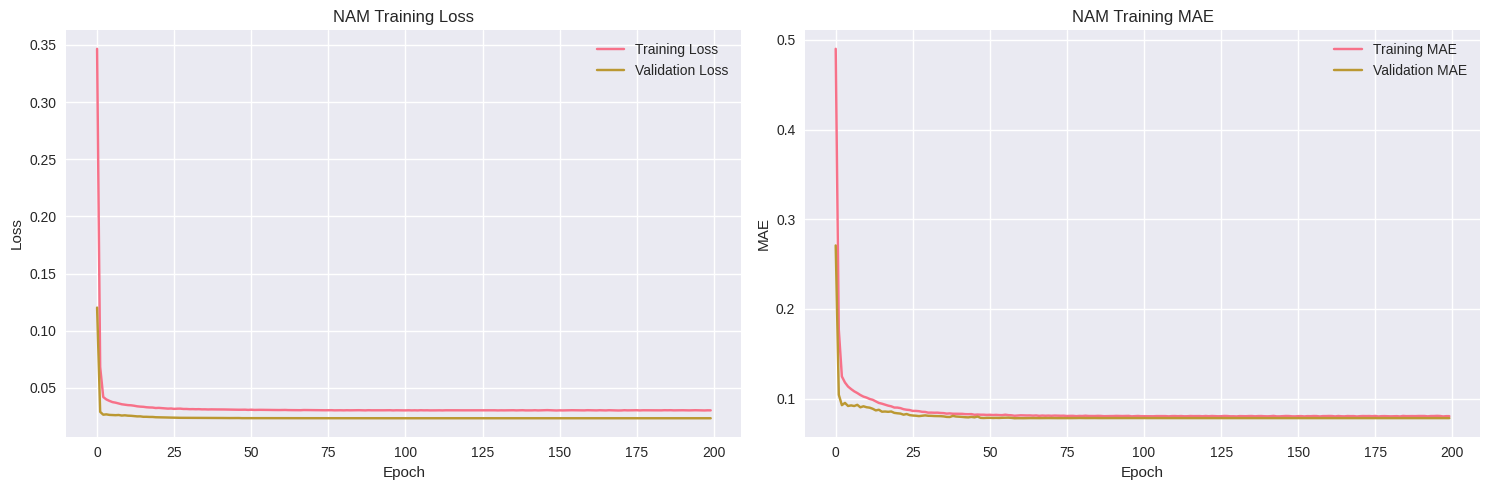

In [27]:
# %%
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('NAM Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('NAM Training MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()

plt.tight_layout()
plt.show()

In [28]:
# NAM Performance Evaluation
nam_predictions = nam_model.predict(X_test_scaled)

# Calculate metrics for each output bus
nam_rmse_per_bus = []
nam_mae_per_bus = []
nam_r2_per_bus = []

for i in range(33):
    rmse = np.sqrt(mean_squared_error(y_test[:, i], nam_predictions[:, i]))
    mae = mean_absolute_error(y_test[:, i], nam_predictions[:, i])
    r2 = r2_score(y_test[:, i], nam_predictions[:, i])
    
    nam_rmse_per_bus.append(rmse)
    nam_mae_per_bus.append(mae)
    nam_r2_per_bus.append(r2)

# Overall metrics
nam_rmse_overall = np.sqrt(mean_squared_error(y_test, nam_predictions))
nam_mae_overall = mean_absolute_error(y_test, nam_predictions)
nam_r2_overall = r2_score(y_test, nam_predictions)

print(f"NAM Overall Performance:")
print(f"RMSE: {nam_rmse_overall:.4f}")
print(f"MAE: {nam_mae_overall:.4f}")
print(f"R²: {nam_r2_overall:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
NAM Overall Performance:
RMSE: 0.1528
MAE: 0.0782
R²: -2.3562


In [29]:
# ## 5. NAM Interpretability Analysis - Feature Function Plots

# %%
# Get feature contributions for selected features
selected_features = ['Tap1', 'PV3loc', 'PV3size']
selected_indices = [0, 4, 9]  # Corresponding indices
selected_buses = [6, 18, 29]  # Representative output buses

# Generate feature range for plotting
feature_ranges = {}
feature_names = ['Tap1', 'Tap2', 'PV1loc', 'PV2loc', 'PV3loc', 'PV4loc', 'PV5loc', 
                'PV1size', 'PV2size', 'PV3size', 'PV4size', 'PV5size']

for i, feature in enumerate(feature_names):
    min_val = X_train_scaled[:, i].min()
    max_val = X_train_scaled[:, i].max()
    feature_ranges[feature] = np.linspace(min_val, max_val, 100)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


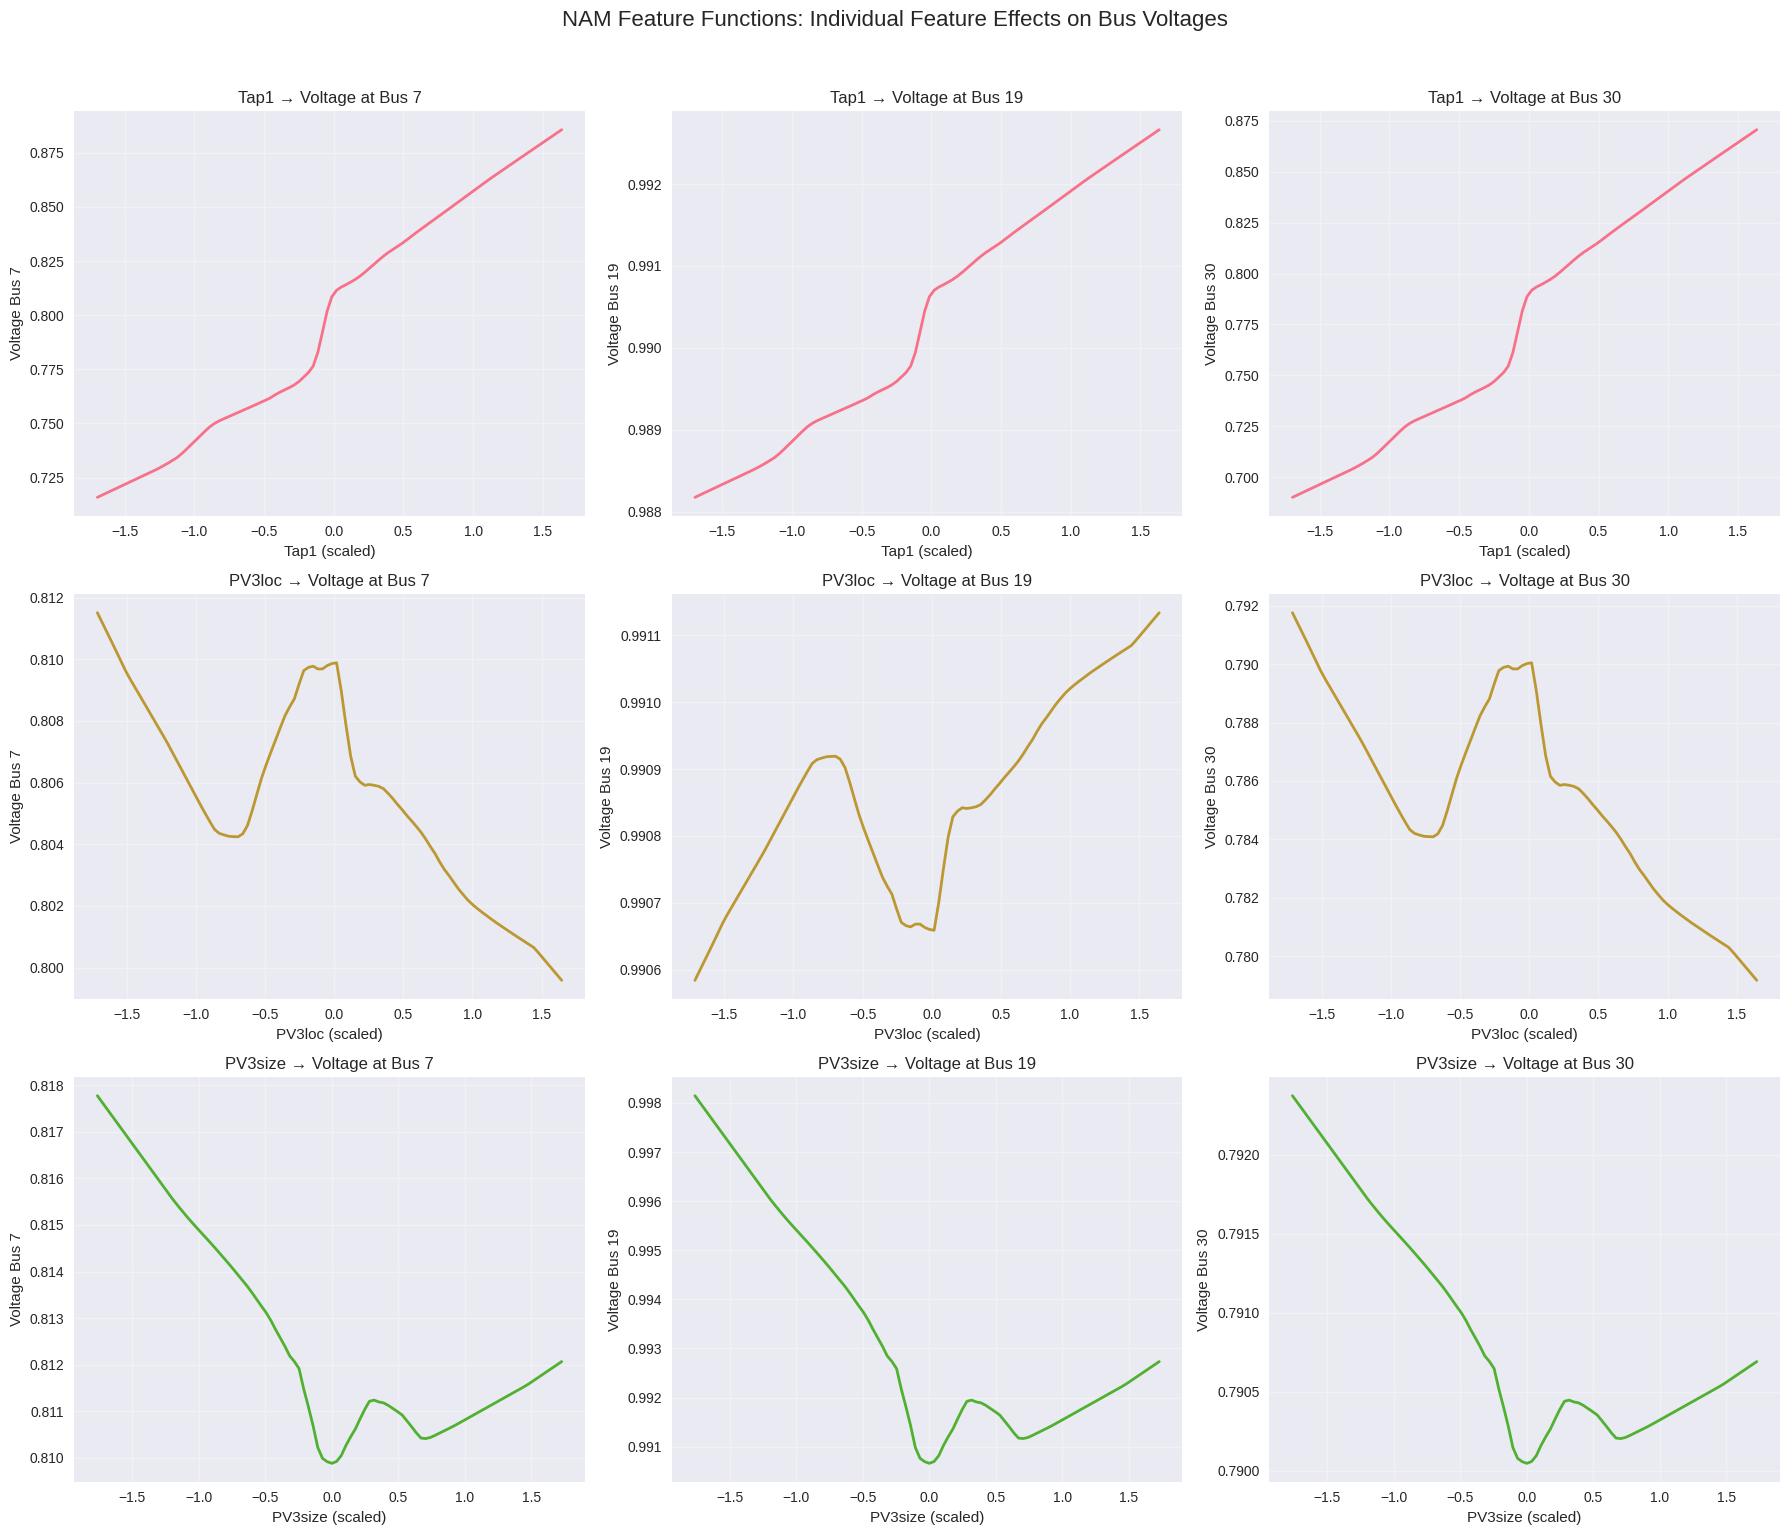

In [30]:
# Plot feature functions for selected features
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, (feature_name, feature_idx) in enumerate(zip(selected_features, selected_indices)):
    for j, bus_idx in enumerate(selected_buses):
        # Create input array with mean values for all features
        mean_inputs = np.tile(X_train_scaled.mean(axis=0), (100, 1))
        # Vary the selected feature
        mean_inputs[:, feature_idx] = feature_ranges[feature_name]
        
        # Get predictions
        predictions = nam_model.predict(mean_inputs)
        
        # Plot feature effect on specific bus
        axes[i, j].plot(feature_ranges[feature_name], predictions[:, bus_idx], 
                       linewidth=2, color=f'C{i}')
        axes[i, j].set_title(f'{feature_name} → Voltage at Bus {bus_idx + 1}')
        axes[i, j].set_xlabel(f'{feature_name} (scaled)')
        axes[i, j].set_ylabel(f'Voltage Bus {bus_idx + 1}')
        axes[i, j].grid(True, alpha=0.3)

plt.suptitle('NAM Feature Functions: Individual Feature Effects on Bus Voltages', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

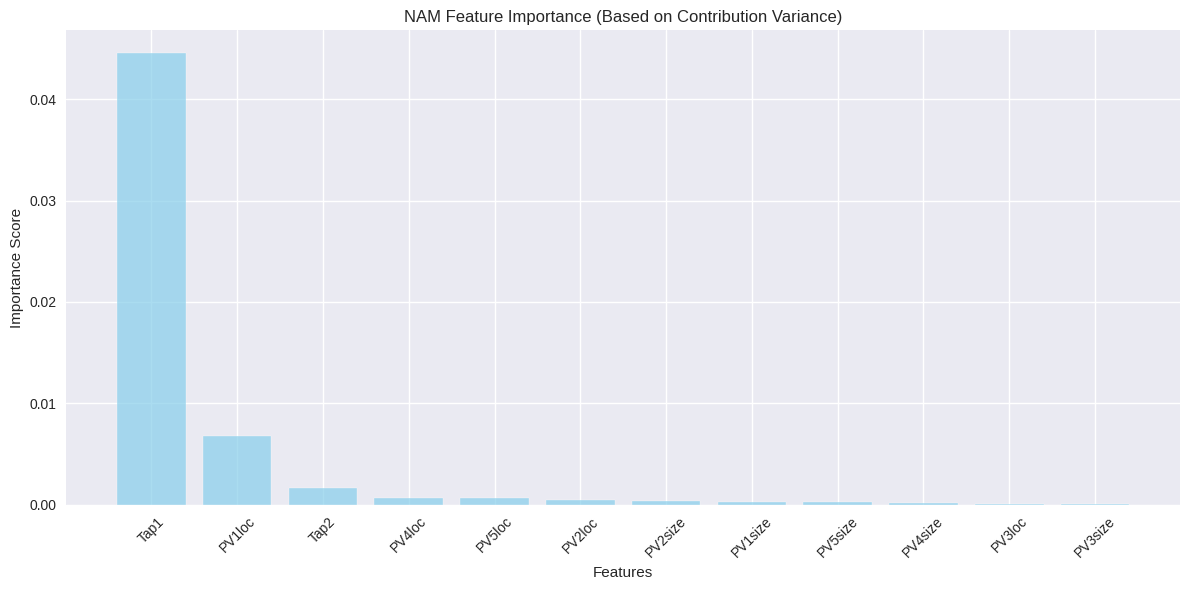

NAM Feature Importance Analysis:
Tap1: 0.044556
PV1loc: 0.006824
Tap2: 0.001607
PV4loc: 0.000693
PV5loc: 0.000647
PV2loc: 0.000486
PV2size: 0.000378
PV1size: 0.000312
PV5size: 0.000235
PV4size: 0.000131
PV3loc: 0.000104
PV3size: 0.000050


In [31]:
# ## 6. Feature Importance Analysis for NAM

# %%
# Calculate feature importance based on variance of feature contributions
feature_importance_nam = {}
feature_names = ['Tap1', 'Tap2', 'PV1loc', 'PV2loc', 'PV3loc', 'PV4loc', 'PV5loc', 
                'PV1size', 'PV2size', 'PV3size', 'PV4size', 'PV5size']

# Get feature contributions on test set
contributions = nam_model.get_feature_contributions(X_test_scaled)

# Calculate importance as variance of contributions across samples
for feature in feature_names:
    # Average importance across all output buses
    feature_importance_nam[feature] = np.mean(np.var(contributions[feature], axis=0))

# Plot NAM feature importance
plt.figure(figsize=(12, 6))
sorted_features = sorted(feature_importance_nam.items(), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

plt.bar(features, importances, color='skyblue', alpha=0.7)
plt.title('NAM Feature Importance (Based on Contribution Variance)')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print feature importance analysis
print("NAM Feature Importance Analysis:")
for feature, importance in sorted_features:
    print(f"{feature}: {importance:.6f}")

In [32]:
# ## 7. Baseline Models Training (XGBoost and Random Forest)

# %%
# XGBoost Multi-output Regressor
print("Training XGBoost model...")
xgb_regressor = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
)

xgb_regressor.fit(X_train_scaled, y_train)
xgb_predictions = xgb_regressor.predict(X_test_scaled)

print("XGBoost training completed!")

# %%
# Random Forest Multi-output Regressor
print("Training Random Forest model...")
rf_regressor = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
)

rf_regressor.fit(X_train_scaled, y_train)
rf_predictions = rf_regressor.predict(X_test_scaled)

print("Random Forest training completed!")

Training XGBoost model...
XGBoost training completed!
Training Random Forest model...
Random Forest training completed!


Model Performance Comparison:
        Model   RMSE    MAE      R²
          NAM 0.1528 0.0782 -2.3562
      XGBoost 0.1558 0.0729  0.2922
Random Forest 0.1483 0.0700  0.3260


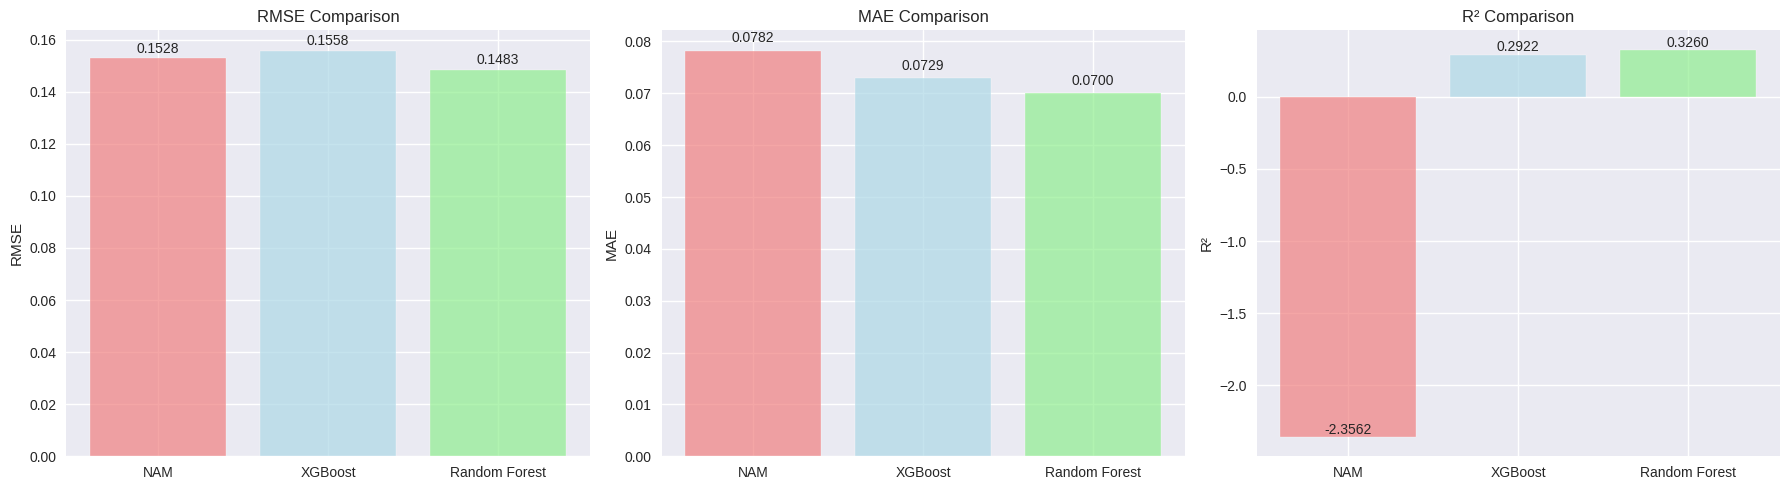

In [33]:
# ## 8. Baseline Models Performance Evaluation

# %%
# XGBoost Performance
xgb_rmse_overall = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae_overall = mean_absolute_error(y_test, xgb_predictions)
xgb_r2_overall = r2_score(y_test, xgb_predictions)

# Random Forest Performance
rf_rmse_overall = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae_overall = mean_absolute_error(y_test, rf_predictions)
rf_r2_overall = r2_score(y_test, rf_predictions)

# Create performance comparison table
performance_data = {
    'Model': ['NAM', 'XGBoost', 'Random Forest'],
    'RMSE': [nam_rmse_overall, xgb_rmse_overall, rf_rmse_overall],
    'MAE': [nam_mae_overall, xgb_mae_overall, rf_mae_overall],
    'R²': [nam_r2_overall, xgb_r2_overall, rf_r2_overall]
}

performance_df = pd.DataFrame(performance_data)
print("Model Performance Comparison:")
print(performance_df.to_string(index=False, float_format='%.4f'))

# Visualize performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSE', 'MAE', 'R²']
for i, metric in enumerate(metrics):
    axes[i].bar(performance_df['Model'], performance_df[metric], 
                color=['lightcoral', 'lightblue', 'lightgreen'], alpha=0.7)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    for j, v in enumerate(performance_df[metric]):
        axes[i].text(j, v + (0.001 if metric != 'R²' else 0.001), f'{v:.4f}', 
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


Calculating SHAP values for XGBoost...
SHAP values calculated!


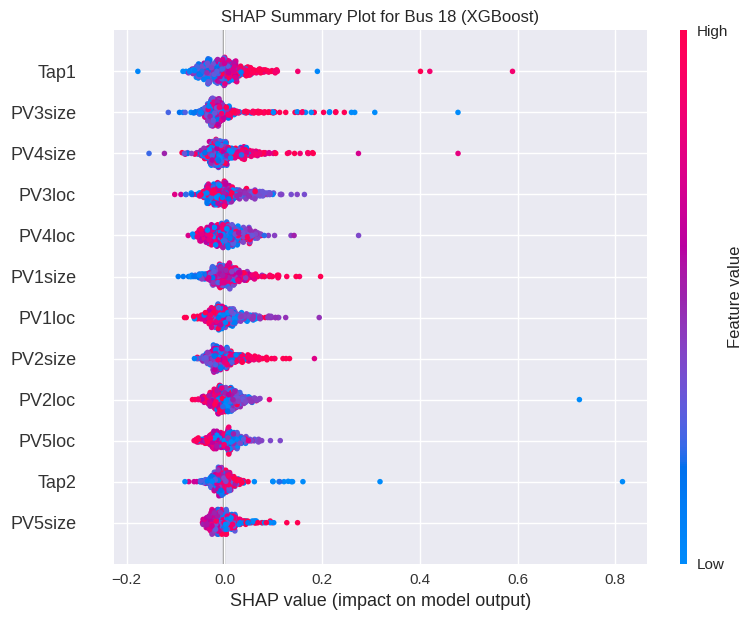

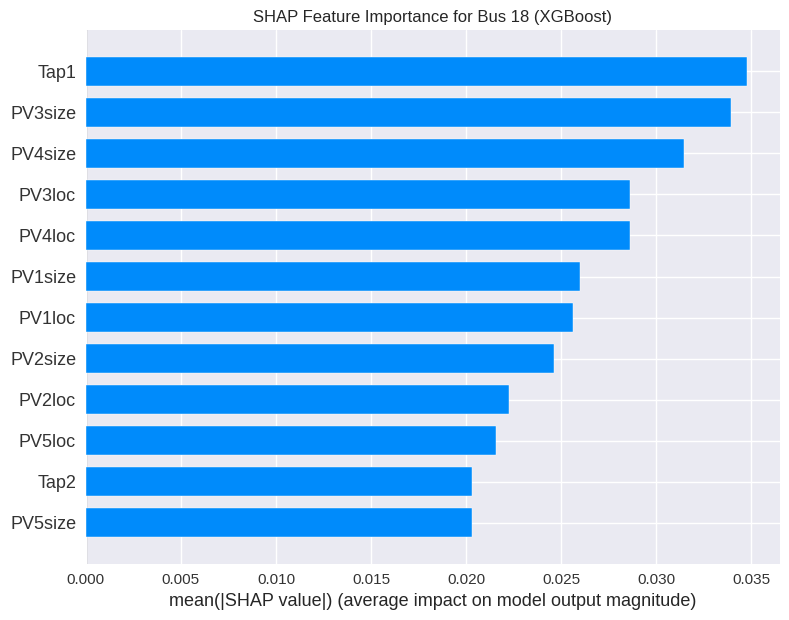

In [34]:
# ## 9. SHAP Analysis for XGBoost

# %%
# SHAP Analysis for XGBoost
print("Calculating SHAP values for XGBoost...")

# We'll analyze SHAP for a single output (Bus 18 as example)
target_bus = 17  # Bus 18 (0-indexed)

# Get single-output XGBoost model for SHAP analysis
xgb_single = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_single.fit(X_train_scaled, y_train[:, target_bus])

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_single)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values calculated!")

# %%
# SHAP Global Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title(f'SHAP Summary Plot for Bus {target_bus + 1} (XGBoost)')
plt.tight_layout()
plt.show()

# %%
# SHAP Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance for Bus {target_bus + 1} (XGBoost)')
plt.tight_layout()
plt.show()

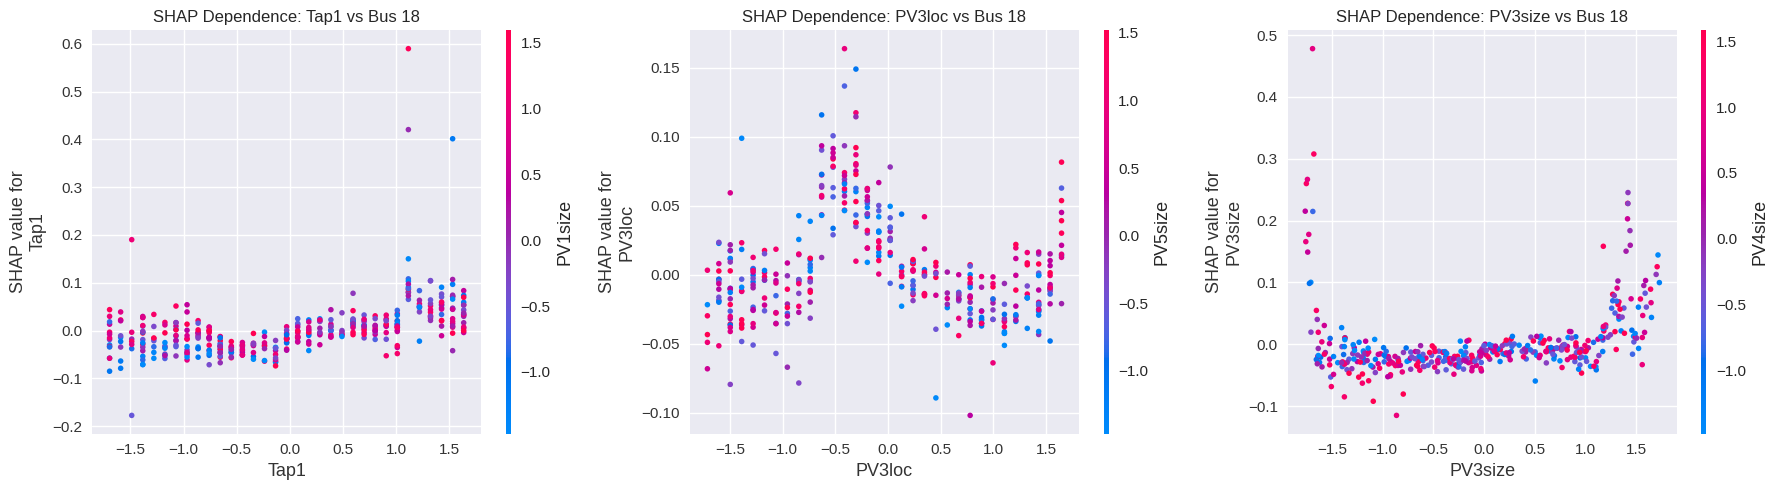

In [35]:
# SHAP Dependence Plots for selected features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (feature_name, feature_idx) in enumerate(zip(selected_features, selected_indices)):
    shap.dependence_plot(feature_idx, shap_values, X_test_scaled, 
                        feature_names=feature_names, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feature_name} vs Bus {target_bus + 1}')

plt.tight_layout()
plt.show()

In [36]:
# ## 10. SHAP Analysis for Random Forest

# %%
# SHAP Analysis for Random Forest
print("Calculating SHAP values for Random Forest...")

# Single-output Random Forest for SHAP
rf_single = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_single.fit(X_train_scaled, y_train[:, target_bus])

# Create SHAP explainer for Random Forest
rf_explainer = shap.TreeExplainer(rf_single)
rf_shap_values = rf_explainer.shap_values(X_test_scaled)

print("Random Forest SHAP values calculated!")


Calculating SHAP values for Random Forest...
Random Forest SHAP values calculated!


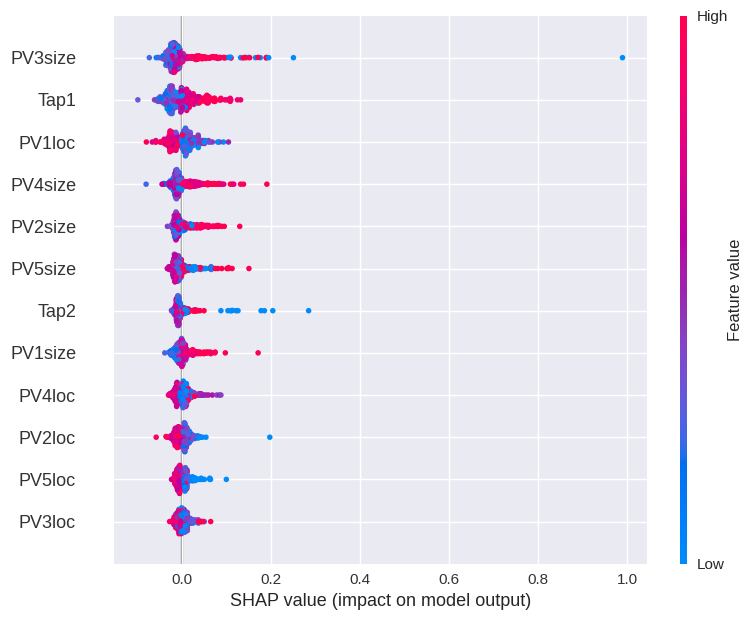

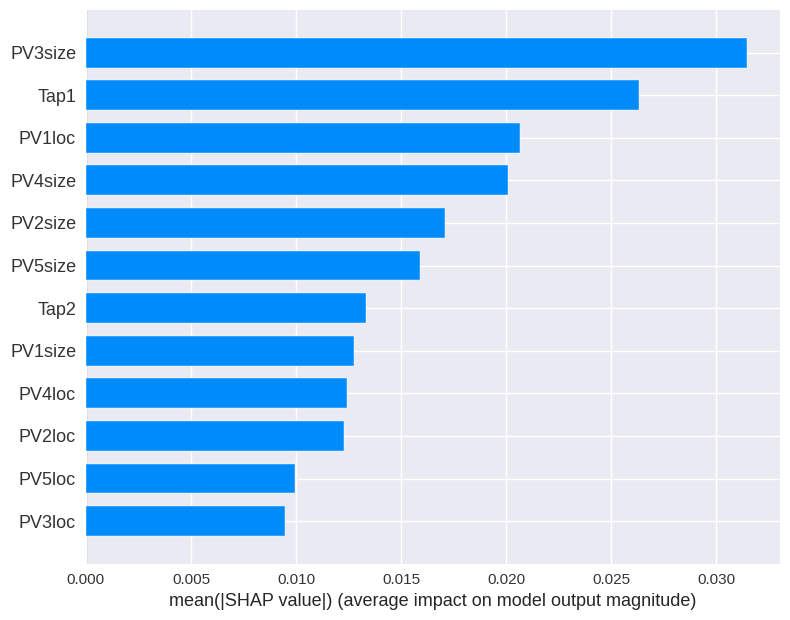

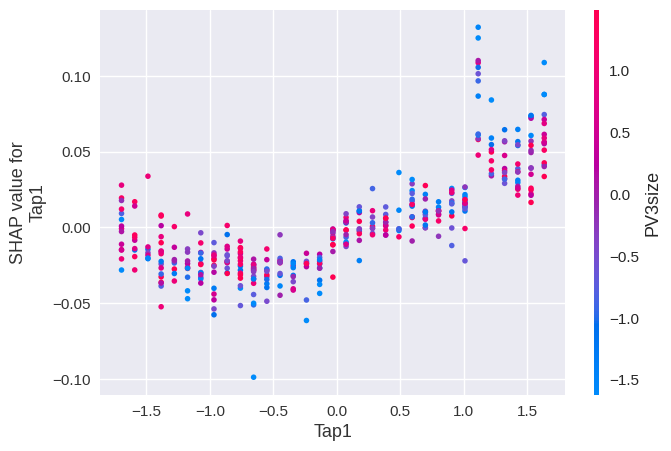

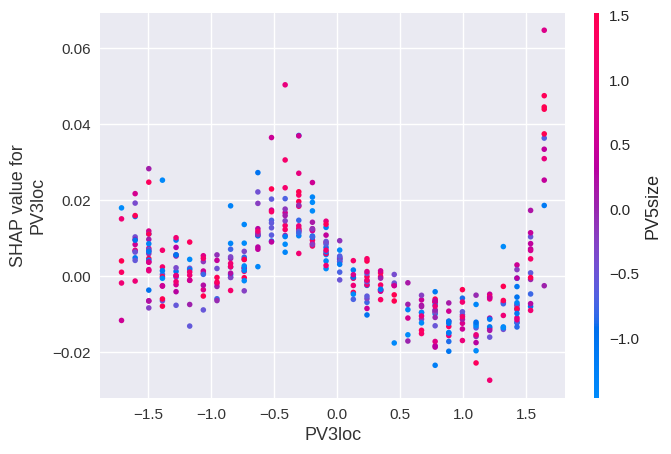

<Figure size 800x550 with 0 Axes>

In [37]:
# Random Forest SHAP Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Summary plot
shap.summary_plot(rf_shap_values, X_test_scaled, feature_names=feature_names, show=True)
axes[0,0].set_title(f'RF SHAP Summary - Bus {target_bus + 1}')

# Feature importance
shap.summary_plot(rf_shap_values, X_test_scaled, feature_names=feature_names, plot_type="bar", show=True)
axes[0,1].set_title(f'RF SHAP Feature Importance - Bus {target_bus + 1}')

# Dependence plots for two key features
shap.dependence_plot(selected_indices[0], rf_shap_values, X_test_scaled, 
                    feature_names=feature_names, show=True)
axes[1,0].set_title(f'RF SHAP Dependence: {selected_features[0]}')

shap.dependence_plot(selected_indices[1], rf_shap_values, X_test_scaled, 
                    feature_names=feature_names, show=True)
axes[1,1].set_title(f'RF SHAP Dependence: {selected_features[1]}')

plt.tight_layout()
plt.show()

Bus-wise Performance Summary:
   Bus  NAM_RMSE  NAM_MAE   NAM_R2  XGB_RMSE  XGB_MAE  XGB_R2  RF_RMSE  RF_MAE   RF_R2
 Bus_1    0.0275   0.0208   0.0000    0.0000   0.0000  1.0000   0.0000  0.0000  1.0000
 Bus_2    0.0222   0.0172 -70.0135    0.0027   0.0017 -0.0287   0.0025  0.0016  0.0684
 Bus_3    0.0235   0.0152  -0.2929    0.0211   0.0122 -0.0464   0.0207  0.0120 -0.0032
 Bus_4    0.0309   0.0202  -0.0492    0.0307   0.0186 -0.0360   0.0296  0.0177  0.0344
 Bus_5    0.0423   0.0279  -0.1129    0.0405   0.0248 -0.0176   0.0391  0.0236  0.0519
 Bus_6    0.0646   0.0418   0.4466    0.0664   0.0412  0.4160   0.0653  0.0403  0.4346
 Bus_7    0.0818   0.0518   0.3260    0.0810   0.0484  0.3380   0.0813  0.0492  0.3332
 Bus_8    0.1157   0.0813   0.2202    0.1202   0.0826  0.1591   0.1151  0.0777  0.2287
 Bus_9    0.1449   0.1014   0.1577    0.1532   0.1048  0.0580   0.1431  0.0968  0.1783
Bus_10    0.1789   0.1239   0.1178    0.1881   0.1288  0.0247   0.1779  0.1195  0.1278


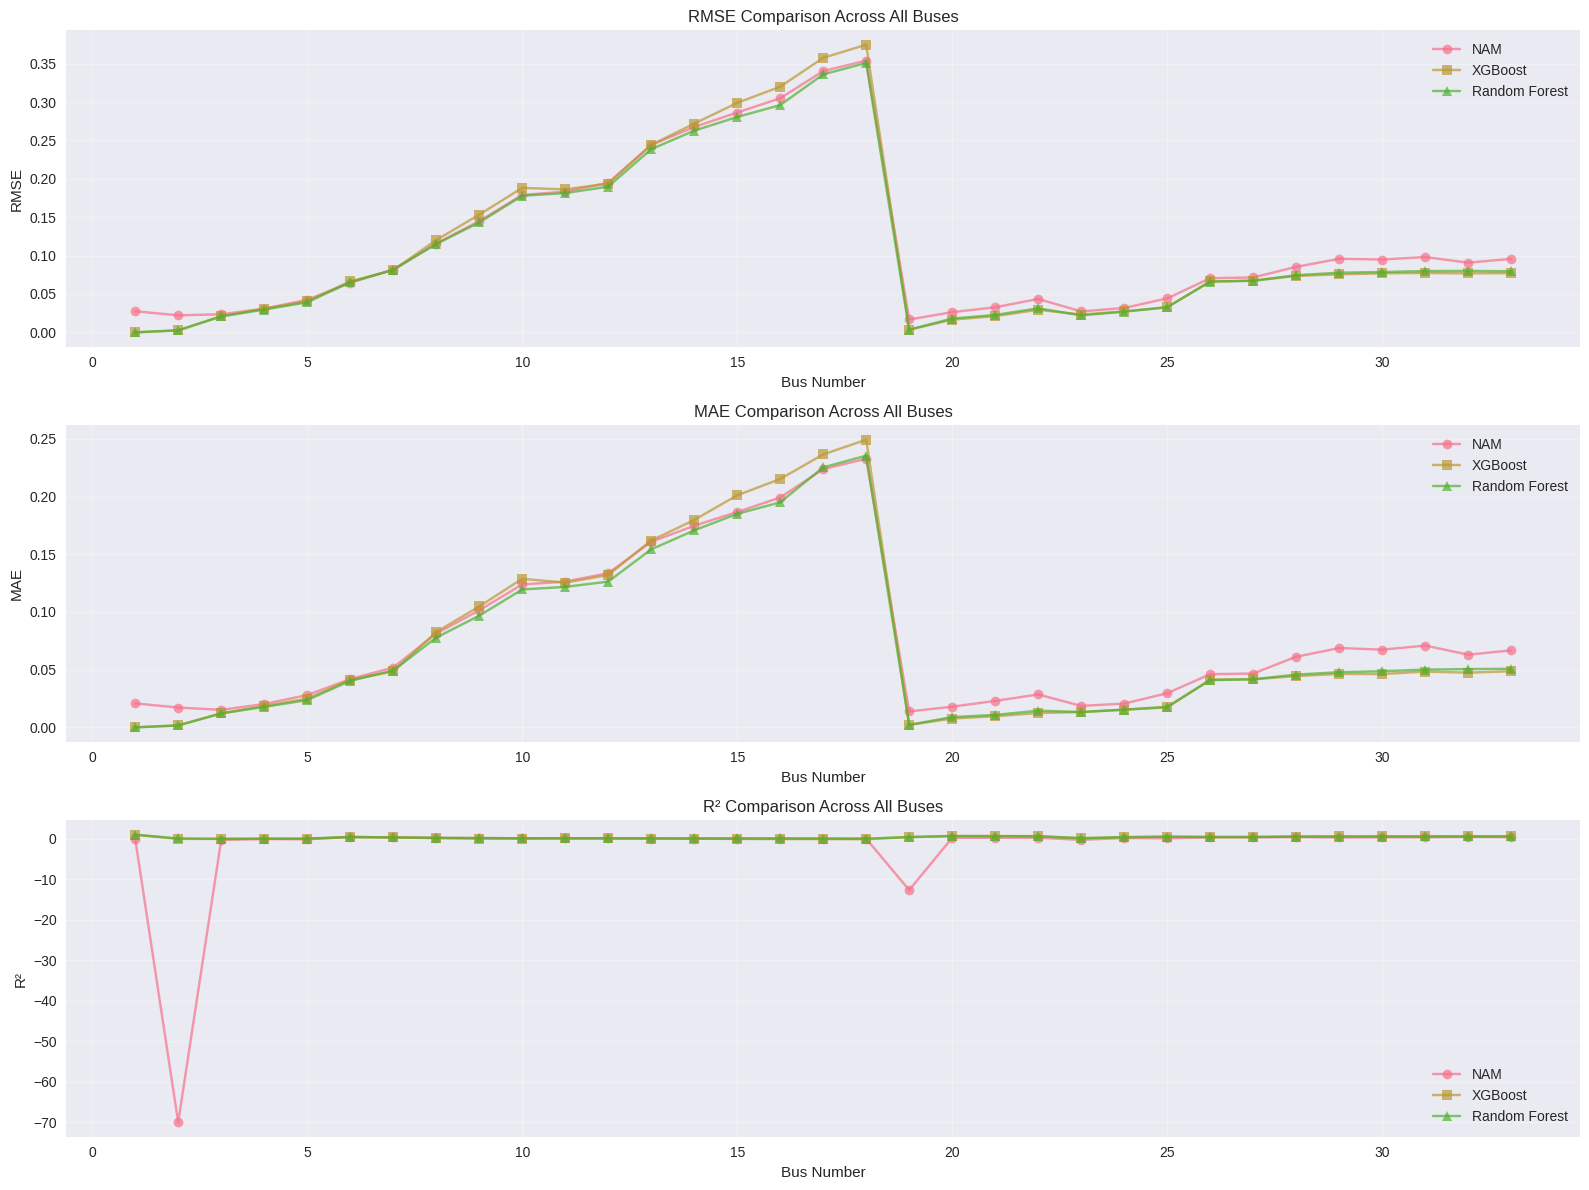

In [38]:
# ## 12. Bus-wise Performance Analysis

# %%
# Calculate per-bus performance for all models
bus_performance = pd.DataFrame({
    'Bus': [f'Bus_{i+1}' for i in range(33)],
    'NAM_RMSE': nam_rmse_per_bus,
    'NAM_MAE': nam_mae_per_bus,
    'NAM_R2': nam_r2_per_bus
})

# Calculate XGBoost and RF per-bus metrics
xgb_rmse_per_bus = []
xgb_mae_per_bus = []
xgb_r2_per_bus = []

rf_rmse_per_bus = []
rf_mae_per_bus = []
rf_r2_per_bus = []

for i in range(33):
    # XGBoost
    xgb_rmse = np.sqrt(mean_squared_error(y_test[:, i], xgb_predictions[:, i]))
    xgb_mae = mean_absolute_error(y_test[:, i], xgb_predictions[:, i])
    xgb_r2 = r2_score(y_test[:, i], xgb_predictions[:, i])
    
    # Random Forest
    rf_rmse = np.sqrt(mean_squared_error(y_test[:, i], rf_predictions[:, i]))
    rf_mae = mean_absolute_error(y_test[:, i], rf_predictions[:, i])
    rf_r2 = r2_score(y_test[:, i], rf_predictions[:, i])
    
    xgb_rmse_per_bus.append(xgb_rmse)
    xgb_mae_per_bus.append(xgb_mae)
    xgb_r2_per_bus.append(xgb_r2)
    
    rf_rmse_per_bus.append(rf_rmse)
    rf_mae_per_bus.append(rf_mae)
    rf_r2_per_bus.append(rf_r2)

bus_performance['XGB_RMSE'] = xgb_rmse_per_bus
bus_performance['XGB_MAE'] = xgb_mae_per_bus
bus_performance['XGB_R2'] = xgb_r2_per_bus
bus_performance['RF_RMSE'] = rf_rmse_per_bus
bus_performance['RF_MAE'] = rf_mae_per_bus
bus_performance['RF_R2'] = rf_r2_per_bus

print("Bus-wise Performance Summary:")
print(bus_performance.head(10).to_string(index=False, float_format='%.4f'))

# %%
# Plot bus-wise performance comparison
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

bus_indices = range(1, 34)

# RMSE comparison
axes[0].plot(bus_indices, bus_performance['NAM_RMSE'], 'o-', label='NAM', alpha=0.7)
axes[0].plot(bus_indices, bus_performance['XGB_RMSE'], 's-', label='XGBoost', alpha=0.7)
axes[0].plot(bus_indices, bus_performance['RF_RMSE'], '^-', label='Random Forest', alpha=0.7)
axes[0].set_title('RMSE Comparison Across All Buses')
axes[0].set_xlabel('Bus Number')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE comparison
axes[1].plot(bus_indices, bus_performance['NAM_MAE'], 'o-', label='NAM', alpha=0.7)
axes[1].plot(bus_indices, bus_performance['XGB_MAE'], 's-', label='XGBoost', alpha=0.7)
axes[1].plot(bus_indices, bus_performance['RF_MAE'], '^-', label='Random Forest', alpha=0.7)
axes[1].set_title('MAE Comparison Across All Buses')
axes[1].set_xlabel('Bus Number')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# R² comparison
axes[2].plot(bus_indices, bus_performance['NAM_R2'], 'o-', label='NAM', alpha=0.7)
axes[2].plot(bus_indices, bus_performance['XGB_R2'], 's-', label='XGBoost', alpha=0.7)
axes[2].plot(bus_indices, bus_performance['RF_R2'], '^-', label='Random Forest', alpha=0.7)
axes[2].set_title('R² Comparison Across All Buses')
axes[2].set_xlabel('Bus Number')
axes[2].set_ylabel('R²')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
# ## 13. Key Findings and Conclusions

# %%
print("=" * 80)
print("KEY FINDINGS AND CONCLUSIONS")
print("=" * 80)

print("\n1. MODEL PERFORMANCE COMPARISON:")
print(f"   NAM        - RMSE: {nam_rmse_overall:.4f}, MAE: {nam_mae_overall:.4f}, R²: {nam_r2_overall:.4f}")
print(f"   XGBoost    - RMSE: {xgb_rmse_overall:.4f}, MAE: {xgb_mae_overall:.4f}, R²: {xgb_r2_overall:.4f}")
print(f"   Random Forest - RMSE: {rf_rmse_overall:.4f}, MAE: {rf_mae_overall:.4f}, R²: {rf_r2_overall:.4f}")

# Determine best performing model
best_rmse = min(nam_rmse_overall, xgb_rmse_overall, rf_rmse_overall)
best_model_rmse = ['NAM', 'XGBoost', 'Random Forest'][np.argmin([nam_rmse_overall, xgb_rmse_overall, rf_rmse_overall])]
print(f"\n   Best performing model (RMSE): {best_model_rmse}")

print("\n2. INTERPRETABILITY ANALYSIS:")
print("   NAM provides inherent interpretability through feature-specific subnetworks")


KEY FINDINGS AND CONCLUSIONS

1. MODEL PERFORMANCE COMPARISON:
   NAM        - RMSE: 0.1528, MAE: 0.0782, R²: -2.3562
   XGBoost    - RMSE: 0.1558, MAE: 0.0729, R²: 0.2922
   Random Forest - RMSE: 0.1483, MAE: 0.0700, R²: 0.3260

   Best performing model (RMSE): Random Forest

2. INTERPRETABILITY ANALYSIS:
   NAM provides inherent interpretability through feature-specific subnetworks
